# NYC Data

Importación de las librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import geopandas as gpd
import folium



## Lectura de datos



```{note}
para la lectura de los datos en formato *`.parquet`* se instala una extensión de la libreria pandas, tal como se muestra a continuación*`pip install pandas fastparquet`* 
```

In [3]:
df_taxi = pd.read_parquet(r'C:\Users\PC\Desktop\ML_clase\jbook_ml20251\data\yellow_tripdata_2019-01.parquet')
df_taxi.shape

(7696617, 19)

In [4]:
df_taxi.head(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.00,0.3,9.95,NaN,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.00,0.3,16.30,NaN,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.00,0.3,5.80,NaN,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.00,0.3,7.55,NaN,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
5,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,5.76,0.3,13.31,NaN,NaN
6,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
7,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,6.5,0.5,0.5,1.25,0.00,0.3,9.05,NaN,NaN
8,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,13.5,0.5,0.5,3.70,0.00,0.3,18.50,NaN,NaN
9,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,10.0,0.5,0.5,1.70,0.00,0.3,13.00,NaN,NaN


In [5]:
df_taxi.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,7.696617e+06,7696617,7696617,7.667945e+06,7.696617e+06,7.667945e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,7.696617e+06,2.811730e+06,0.0
mean,1.638174e+00,2019-01-17 00:56:26.319619072,2019-01-17 01:12:59.384516352,1.567032e+00,2.830146e+00,1.058371e+00,1.654005e+02,1.636289e+02,1.286947e+00,1.252968e+01,3.374054e-01,4.964963e-01,1.820830e+00,3.229543e-01,2.993410e-01,1.581065e+01,3.289790e-05,NaN
min,1.000000e+00,2001-02-02 14:55:07,2001-02-02 15:07:27,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-3.620000e+02,-6.000000e+01,-5.000000e-01,-6.350000e+01,-7.000000e+01,-3.000000e-01,-3.628000e+02,0.000000e+00,NaN
25%,1.000000e+00,2019-01-09 17:39:43,2019-01-09 17:55:48,1.000000e+00,9.000000e-01,1.000000e+00,1.270000e+02,1.130000e+02,1.000000e+00,6.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,0.000000e+00,NaN
50%,2.000000e+00,2019-01-16 22:15:35,2019-01-16 22:30:08,1.000000e+00,1.530000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.400000e+00,0.000000e+00,3.000000e-01,1.130000e+01,0.000000e+00,NaN
75%,2.000000e+00,2019-01-24 19:12:20,2019-01-24 19:27:57,2.000000e+00,2.830000e+00,1.000000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.320000e+00,0.000000e+00,3.000000e-01,1.660000e+01,0.000000e+00,NaN
max,5.000000e+00,2088-01-24 00:25:39,2088-01-24 07:28:25,9.000000e+00,8.318000e+02,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.232599e+05,5.353800e+02,6.080000e+01,7.872500e+02,3.288000e+03,6.000000e-01,6.232617e+05,2.500000e+00,NaN
std,5.393984e-01,NaN,NaN,1.224420e+00,3.774548e+00,6.780839e-01,6.643992e+01,7.040929e+01,4.789416e-01,2.615897e+02,5.313564e-01,5.492382e-02,2.499463e+00,2.029812e+00,1.907704e-02,2.618117e+02,9.068830e-03,NaN


Para las variables tpep_pickup_datetime y tpep_dropoff_datetime se observa que el valor max corresponde a fecha del 2088, lo que puede ser un posible error de digitalización, por lo tanto se deben filtratr los viajes fuera del rango lógico (fuera de del año 2019)

### Georreferenciación de las zonas de inicio y finalización de la carrera

```{note}
se realiza un merge con un archivo externo para obtener las zonas de origen y destino
```

In [6]:
zonas_df = pd.read_csv(r"C:\Users\PC\Desktop\ML_clase\jbook_ml20251\data\taxi+_zone_lookup.csv")
# Unir el DataFrame de taxis con las zonas usando PULocationID
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='PULocationID', right_on='LocationID', how='left')

# Unir también el DOLocationID para obtener la zona de destino
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='DOLocationID', right_on='LocationID', how='left', suffixes=('_pickup', '_dropoff'))

In [7]:
# Revisar si hubo alguna falla en el mapeo (zonas no encontradas)
missing_zones = df_taxi[['Zone_pickup', 'Zone_dropoff']].isnull().sum()
print("Zonas no encontradas:\n", missing_zones)

Zonas no encontradas:
 Zone_pickup      3890
Zone_dropoff    16904
dtype: int64


In [8]:
# Se eliminan estas zonas no encontradas para realizar el analisis geoespacial, dado que solo representan el 0.05% y 0.22% de los datos totaless:
print(f"Tamaño del dataset inicialmente: {df_taxi.shape}")
df_taxi = df_taxi.dropna(subset=['Zone_pickup', 'Zone_dropoff'])
print(f"Nuevo tamaño del dataset: {df_taxi.shape}")
missing_zones = df_taxi[['Zone_pickup', 'Zone_dropoff']].isnull().sum()
print("Zonas no encontradas:\n", missing_zones)
df_taxi.head(5)

Tamaño del dataset inicialmente: (7696617, 23)
Nuevo tamaño del dataset: (7678865, 23)
Zonas no encontradas:
 Zone_pickup     0
Zone_dropoff    0
dtype: int64


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,LocationID_pickup,Zone_pickup,LocationID_dropoff,Zone_dropoff
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,...,1.65,0.0,0.3,9.95,NaN,NaN,151,Manhattan Valley,239,Upper West Side South
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,...,1.00,0.0,0.3,16.30,NaN,NaN,239,Upper West Side South,246,West Chelsea/Hudson Yards
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,...,0.00,0.0,0.3,5.80,NaN,NaN,236,Upper East Side North,236,Upper East Side North
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,...,0.00,0.0,0.3,7.55,NaN,NaN,193,Queensbridge/Ravenswood,193,Queensbridge/Ravenswood
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,...,0.00,0.0,0.3,55.55,NaN,NaN,193,Queensbridge/Ravenswood,193,Queensbridge/Ravenswood


In [9]:


# Coordenadas de algunas zonas de recogida y entrega (ejemplo)
pickup_zones_coords = {
    'Manhattan Valley': [40.8071, -73.9610],
    'Upper West Side South': [40.7850, -73.9750],
    'Upper East Side North': [40.7847, -73.9523],
    'Queensbridge/Ravenswood': [40.7612, -73.9442],
    'Midtown North': [40.7549, -73.9808],
    'Sutton Place/Turtle Bay North': [40.7566, -73.9689],
    'Lenox Hill West': [40.7661, -73.9630],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Stuy Town/Peter Cooper Village': [40.7311, -73.9790],
    'Murray Hill': [40.7450, -73.9819],
    'Gramercy': [40.7365, -73.9857],
    'Central Harlem': [40.8115, -73.9465],
    'Hamilton Heights': [40.8230, -73.9453],
    'Greenwich Village North': [40.7375, -73.9987],
    'Midtown Center': [40.7550, -73.9850],
    'LaGuardia Airport': [40.7769, -73.8737],
    'Little Italy/NoLiTa': [40.7223, -73.9963],
    'TriBeCa/Civic Center': [40.7168, -74.0070],
    'Upper East Side South': [40.7736, -73.9567],
    'Yorkville West': [40.7741, -73.9503],
    'JFK Airport': [40.6413, -73.7781],
    'NV': [40.7038, -74.0148],
    'Lincoln Square East': [40.7713, -73.9863],
    'West Village': [40.7336, -74.0033],
    'Kips Bay': [40.7422, -73.9763],
    'Flatiron': [40.7411, -73.9897],
    'Midtown East': [40.7551, -73.9760],
    'Lenox Hill East': [40.7673, -73.9579],
    'East Chelsea': [40.7450, -73.9989],
    'Financial District South': [40.7057, -74.0125],
    'East Harlem North': [40.7954, -73.9384],
    'East Village': [40.7250, -73.9816],
    'East Harlem South': [40.7982, -73.9405],
    'UN/Turtle Bay South': [40.7484, -73.9680],
    'Lower East Side': [40.7158, -73.9848],
    'Clinton East': [40.7590, -73.9900],
    'Lincoln Square West': [40.7702, -73.9873],
    'Alphabet City': [40.7261, -73.9819],
    'Midtown South': [40.7440, -73.9930],
    'Two Bridges/Seward Park': [40.7110, -73.9865],
    'Chinatown': [40.7150, -73.9985],
    'Central Park': [40.7851, -73.9683],
    'Penn Station/Madison Sq West': [40.7500, -73.9933],
    'Meatpacking/West Village West': [40.7400, -74.0065],
    'Clinton West': [40.7485, -73.9962],
    'Greenwich Village South': [40.7323, -73.9988],
    'Central Harlem North': [40.8105, -73.9440],
    'Bay Ridge': [40.6300, -74.0280],
    'Bath Beach': [40.6075, -73.9887],
    'Park Slope': [40.6625, -73.9895],
    'SoHo': [40.7244, -73.9973],
    'Battery Park City': [40.7130, -74.0160],
    'World Trade Center': [40.7115, -74.0134],
    'Fort Greene': [40.6928, -73.9745],
    'Union Sq': [40.7359, -73.9911],
    'Hudson Sq': [40.7275, -74.0063],
    'Long Island City/Hunters Point': [40.7451, -73.9524],
    'Yorkville East': [40.7729, -73.9511],
    'Sunnyside': [40.7461, -73.9245],
    'Bloomingdale': [40.7620, -73.9886],
    'Morningside Heights': [40.8100, -73.9640],
    'East Williamsburg': [40.7106, -73.9499],
    'Prospect Heights': [40.6740, -73.9640],
    'Brooklyn Heights': [40.6960, -73.9970],
    'Garment District': [40.7550, -73.9940],
    'Hunts Point': [40.8270, -73.8798],
    'Melrose South': [40.8190, -73.9190],
    'Washington Heights South': [40.8450, -73.9400],
    'Washington Heights North': [40.8630, -73.9310],
    'Seaport': [40.7090, -74.0036],
    'Financial District North': [40.7080, -74.0100],
    'Boerum Hill': [40.6834, -73.9912],
    'Woodside': [40.7459, -73.8881],
    'Steinway': [40.7651, -73.9065],
    'Rego Park': [40.7255, -73.8576],
    'Manhattanville': [40.8250, -73.9575],
    'Times Sq/Theatre District': [40.7580, -73.9855],
    'Astoria': [40.7644, -73.9249],
    'DUMBO/Vinegar Hill': [40.7033, -73.9870],
    'Sunset Park West': [40.6402, -74.0103],
    'University Heights/Morris Heights': [40.8670, -73.9204],
    'Kew Gardens': [40.7197, -73.8449],
    'Downtown Brooklyn/MetroTech': [40.6928, -73.9866],
    'Jackson Heights': [40.7511, -73.8830],
    'Elmhurst': [40.7411, -73.8805],
    'Red Hook': [40.6754, -74.0143],
    'Williamsburg (North Side)': [40.7162, -73.9546],
    'Old Astoria': [40.7712, -73.9221],
    'Mount Hope': [40.8616, -73.8942],
    'Flatbush/Ditmas Park': [40.6367, -73.9625],
    'Bushwick South': [40.6770, -73.9210],
    'Bedford': [40.7113, -73.9551],
    'Stuyvesant Heights': [40.6754, -73.9200],
    'Battery Park': [40.7072, -74.0134],
    'Cobble Hill': [40.6857, -73.9982],
    'Greenpoint': [40.7400, -73.9510],
    'Williamsburg (South Side)': [40.7086, -73.9571],
    'Crown Heights North': [40.6710, -73.9440],
    'Windsor Terrace': [40.6602, -73.9760],
    'South Jamaica': [40.6699, -73.8046],
    'East Elmhurst': [40.7615, -73.8784],
    'South Williamsburg': [40.7102, -73.9617],
    'Ocean Hill': [40.6761, -73.9189],
    'Clinton Hill': [40.6851, -73.9586],
    'Mott Haven/Port Morris': [40.8084, -73.9143],
    'East New York': [40.6699, -73.8710],
    'Kensington': [40.6432, -73.9774],
    'Ridgewood': [40.7012, -73.9073],
    'Carroll Gardens': [40.6844, -73.9960],
    'West Concourse': [40.8235, -73.9045],
    'Williamsbridge/Olinville': [40.8794, -73.8681],
    'South Ozone Park': [40.6752, -73.8261],
    'East New York/Pennsylvania Avenue': [40.6747, -73.8877],
    'Westchester Village/Unionport': [40.8401, -73.8694],
    'Highbridge': [40.8470, -73.9240],
    'Gowanus': [40.6750, -73.9890],
    'Schuylerville/Edgewater Park': [40.8580, -73.8267],
    'Crotona Park East': [40.8499, -73.9072],
    'Long Island City/Queens Plaza': [40.7445, -73.9482],
    'Queens Village': [40.7280, -73.7705],
    'Columbia Street': [40.6785, -73.9942],
    'Saint Albans': [40.6950, -73.7734],
    'Bushwick North': [40.7039, -73.9227],
    'Marble Hill': [40.8692, -73.9195],
    'Brooklyn Navy Yard': [40.7241, -73.9755],
    'East Tremont': [40.8614, -73.8670],
    'Jamaica': [40.6695, -73.7950],
    'Van Cortlandt Village': [40.8766, -73.9025],
    'East Concourse/Concourse Village': [40.8382, -73.9266],
    'Howard Beach': [40.6565, -73.8477],
    'Prospect Park': [40.6602, -73.9689],
    'Rosedale': [40.6715, -73.7628],
    'Bellerose': [40.7363, -73.7498],
    'Soundview/Castle Hill': [40.8287, -73.8580],
    'Baisley Park': [40.6744, -73.8192],
    'Springfield Gardens North': [40.6665, -73.7708],
    'Norwood': [40.8760, -73.8902],
    'West Farms/Bronx River': [40.8374, -73.8591],
    'Starrett City': [40.6446, -73.8583],
    'Maspeth': [40.7297, -73.9022],
    'Middle Village': [40.7343, -73.8880],
    'Prospect-Lefferts Gardens': [40.6550, -73.9608],
    'Flushing Meadows-Corona Park': [40.7491, -73.8447],
    'Homecrest': [40.6023, -73.9667],
    'Corona': [40.7423, -73.8608],
    'Richmond Hill': [40.6958, -73.8318]
}

dropoff_zones_coords = {
    'Upper West Side South': [40.7762, -73.9822],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Upper East Side North': [40.7736, -73.9566],
    'Queensbridge/Ravenswood': [40.7590, -73.9442],
    'Sutton Place/Turtle Bay North': [40.7498, -73.9678],
    'Astoria': [40.7690, -73.9442],
    'Union Sq': [40.7359, -73.9911],
    'Midtown East': [40.7486, -73.9739],
    'Manhattan Valley': [40.7900, -73.9549],
    'Boerum Hill': [40.6830, -73.9896],
    'Murray Hill': [40.7411, -73.9887],
    'Gramercy': [40.7369, -73.9876],
    'Lenox Hill West': [40.7750, -73.9580],
    'West Concourse': [40.6840, -73.9950],
    'Central Harlem North': [40.8120, -73.9450],
    'Flatiron': [40.7411, -73.9897],
    'Clinton West': [40.7410, -74.0027],
    'World Trade Center': [40.7115, -74.0134],
    'East Village': [40.7272, -73.9810],
    'Park Slope': [40.6629, -73.9896],
    'NV': [40.7580, -73.9855],
    'Lincoln Square East': [40.7736, -73.9832],
    'Upper West Side North': [40.7790, -73.9810],
    'Elmhurst/Maspeth': [40.7400, -73.8830],
    'Yorkville West': [40.7790, -73.9520],
    'Lenox Hill East': [40.7760, -73.9570],
    'Midtown Center': [40.7480, -73.9845],
    'Kips Bay': [40.7420, -73.9760],
    'Washington Heights North': [40.8610, -73.9330],
    'East Harlem South': [40.7910, -73.9440],
    'Central Harlem': [40.8116, -73.9465],
    'Financial District South': [40.7074, -74.0113],
    'Mott Haven/Port Morris': [40.8170, -73.9220],
    'Greenwich Village North': [40.7336, -74.0027],
    'East Chelsea': [40.7440, -74.0010],
    'Stuy Town/Peter Cooper Village': [40.7360, -73.9810],
    'Greenpoint': [40.7300, -73.9570],
    'Clinton East': [40.7420, -73.9920],
    'UN/Turtle Bay South': [40.7480, -73.9670],
    'West Village': [40.7350, -74.0070],
    'Battery Park City': [40.7030, -74.0170],
    'Alphabet City': [40.7230, -73.9830],
    'Yorkville East': [40.7790, -73.9520],
    'Lower East Side': [40.7180, -73.9840],
    'Two Bridges/Seward Park': [40.7130, -73.9870],
    'Fort Greene': [40.6820, -73.9570],
    'Williamsburg (South Side)': [40.7080, -73.9570],
    'Penn Station/Madison Sq West': [40.7500, -73.9930],
    'Lincoln Square West': [40.7736, -73.9832],
    'Long Island City/Hunters Point': [40.7440, -73.9480],
    'Central Park': [40.7850, -73.9680],
    'Financial District North': [40.7050, -74.0080],
    'Ridgewood': [40.7120, -73.9140],
    'Fresh Meadows': [40.7320, -73.8100],
    'Sunset Park West': [40.6450, -74.0160],
    'Bensonhurst West': [40.6020, -73.9970],
    'Upper East Side South': [40.7740, -73.9520],
    'Steinway': [40.7580, -73.8830],
    'TriBeCa/Civic Center': [40.7180, -74.0080],
    'Midtown South': [40.7400, -73.9900],
    'Meatpacking/West Village West': [40.7400, -74.0050],
    'Washington Heights South': [40.8500, -73.9400],
    'Williamsburg (North Side)': [40.7100, -73.9500],
    'Brownsville': [40.6500, -73.9150],
    'Windsor Terrace': [40.6600, -73.9760],
    'Bushwick South': [40.6780, -73.9230],
    'Elmhurst': [40.7400, -73.8830],
    'Long Island City/Queens Plaza': [40.7440, -73.9480]
}


In [10]:

m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

def add_zone_to_map(zones_coords, color):
    for zone, coords in zones_coords.items():
        folium.CircleMarker(
            location=coords, 
            radius=5,  # Tamaño del círculo
            color=color,  # Color del borde del círculo
            fill=True,  # Llenar el círculo
            fill_color=color,  # Color de relleno
            fill_opacity=0.6  # Opacidad del relleno
        ).add_to(m)

add_zone_to_map(pickup_zones_coords, 'blue')
add_zone_to_map(dropoff_zones_coords, 'red')
m

### Zonas mas recurrentes
El análisis de las 10 zonas con mayor frecuencia de recogida y destino revela patrones interesantes sobre los puntos más activos de la ciudad en términos de transporte de taxis. Las zonas más frecuentes para la recogida de pasajeros incluyen áreas de alto tráfico y centros urbanos clave, como el Upper East Side South, Upper East Side North, y el Midtown Center, que lideran con un número significativo de viajes. En cuanto a los destinos, la Upper East Side North ocupa el primer lugar, seguida de cerca por Upper East Side South y Midtown Center.

Es notable que varias de las mismas zonas que aparecen como las más frecuentadas para la recogida también están entre las más comunes como destinos, lo que sugiere una alta rotación de pasajeros en estas áreas. Sin embargo, también se observan algunas diferencias, como el hecho de que la zona de Murray Hill aparece en el Top 10 de destinos, pero no en el de recogida, lo que podría indicar que es un lugar donde los pasajeros tienden a viajar con frecuencia desde otras zonas. En general, las áreas cercanas a importantes centros comerciales, de negocios y turísticos como Times Square, Penn Station y el Theatre District muestran una gran actividad, lo que refleja el patrón de movilidad típico en ciudades grandes con una alta densidad de población y atracciones principales.


In [11]:
top_pickup_zones = df_taxi['Zone_pickup'].value_counts().head(10)

top_dropoff_zones = df_taxi['Zone_dropoff'].value_counts().head(10)


print("Top 10 Zonas de Recogida:")
print(top_pickup_zones)

print("\nTop 10 Zonas de Destino:")
print(top_dropoff_zones)

Top 10 Zonas de Recogida:
Zone_pickup
Upper East Side South           332712
Upper East Side North           323250
Midtown Center                  312560
Midtown East                    277291
Times Sq/Theatre District       263780
Penn Station/Madison Sq West    260718
Clinton East                    240943
Murray Hill                     239393
Union Sq                        237803
Lincoln Square East             235474
Name: count, dtype: int64

Top 10 Zonas de Destino:
Zone_dropoff
Upper East Side North        334449
Upper East Side South        296332
Midtown Center               294019
Murray Hill                  242422
Midtown East                 232645
Times Sq/Theatre District    225540
Lincoln Square East          214354
Clinton East                 208895
Union Sq                     204529
Upper West Side South        204442
Name: count, dtype: int64


### Preprocesamiento





In [12]:
def process_taxi_data(df_taxi):
    taxi = df_taxi[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
                   'DOLocationID','passenger_count', 'RatecodeID','trip_distance','fare_amount','total_amount', 'payment_type', 
                    'tolls_amount', 'Zone_pickup', 'Zone_dropoff']].copy()
    print(f"Tamaño del dataset inicialmente: {df_taxi.shape}")
    # Renaming Columns
    new_names = {'tpep_pickup_datetime': 'PickUpDate', 'tpep_dropoff_datetime':'DropOffDate', 
                 'passenger_count': 'Passengers', 'trip_distance':'Distance'}
    taxi = taxi.rename(columns=new_names)
    
    # Correct Format in Date Columns
    taxi['PickUpDate'] = pd.to_datetime(taxi['PickUpDate'], format='%Y-%m-%d %H:%M:%S')
    taxi['DropOffDate'] = pd.to_datetime(taxi['DropOffDate'], format='%Y-%m-%d %H:%M:%S')
    # Create Columns for Date Analysis
    taxi['PickUpYear'] = taxi['PickUpDate'].dt.year
    taxi['PickUpMonth'] = taxi['PickUpDate'].dt.month
    taxi['PickUpWeek'] = taxi['PickUpDate'].dt.isocalendar().week
    taxi['PickUpDay'] = taxi['PickUpDate'].dt.day
    taxi['PickUpHour'] = taxi['PickUpDate'].dt.hour
    taxi['PickUpDayWeek'] = taxi['PickUpDate'].dt.dayofweek + 1 
    # Duration Column
    taxi['Duration'] = taxi['DropOffDate'] - taxi['PickUpDate']
    # Total Amount Column
    taxi['total_amount'] = taxi['total_amount'].abs()
    taxi['tolls_amount'] = taxi['tolls_amount'].abs()
    taxi['fare_amount'] = taxi['fare_amount'].abs()
    # Drop Date Columns
    taxi = taxi.drop(labels=['PickUpDate', 'DropOffDate'], axis=1)
    return taxi


taxi_df = process_taxi_data(df_taxi)
taxi_df = taxi_df[['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'RatecodeID','fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth', 'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek','payment_type', 'tolls_amount', 'Duration', 'Zone_pickup', 'Zone_dropoff']]
print(f"Tamaño del dataset taxi_df: {taxi_df.shape}")
taxi_df.head(10)



Tamaño del dataset inicialmente: (7678865, 23)
Tamaño del dataset taxi_df: (7678865, 18)


,PULocationID,DOLocationID,Passengers,Distance,RatecodeID,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration,Zone_pickup,Zone_dropoff
0,151,239,1.0,1.5,1.0,7.0,9.95,2019,1,1,1,0,2,1,0.00,0 days 00:06:40,Manhattan Valley,Upper West Side South
1,239,246,1.0,2.6,1.0,14.0,16.30,2019,1,1,1,0,2,1,0.00,0 days 00:19:12,Upper West Side South,West Chelsea/Hudson Yards
2,236,236,3.0,0.0,1.0,4.5,5.80,2018,12,51,21,13,5,1,0.00,0 days 00:04:10,Upper East Side North,Upper East Side North
3,193,193,5.0,0.0,1.0,3.5,7.55,2018,11,48,28,15,3,2,0.00,0 days 00:03:20,Queensbridge/Ravenswood,Queensbridge/Ravenswood
4,193,193,5.0,0.0,2.0,52.0,55.55,2018,11,48,28,15,3,2,0.00,0 days 00:01:36,Queensbridge/Ravenswood,Queensbridge/Ravenswood
5,193,193,5.0,0.0,1.0,3.5,13.31,2018,11,48,28,16,3,2,5.76,0 days 00:02:37,Queensbridge/Ravenswood,Queensbridge/Ravenswood
6,193,193,5.0,0.0,2.0,52.0,55.55,2018,11,48,28,16,3,2,0.00,0 days 00:04:06,Queensbridge/Ravenswood,Queensbridge/Ravenswood
7,163,229,1.0,1.3,1.0,6.5,9.05,2019,1,1,1,0,2,1,0.00,0 days 00:07:09,Midtown North,Sutton Place/Turtle Bay North
8,229,7,1.0,3.7,1.0,13.5,18.50,2019,1,1,1,0,2,1,0.00,0 days 00:13:38,Sutton Place/Turtle Bay North,Astoria
9,141,234,2.0,2.1,1.0,10.0,13.00,2019,1,1,1,0,2,1,0.00,0 days 00:12:00,Lenox Hill West,Union Sq


In [13]:
# Filtrar los registros cuyo año de recogida sea exactamente 2019
taxi_df = taxi_df[taxi_df['PickUpYear'] == 2019]
print(taxi_df['PickUpYear'].describe())

count    7678425.0
mean        2019.0
std            0.0
min         2019.0
25%         2019.0
50%         2019.0
75%         2019.0
max         2019.0
Name: PickUpYear, dtype: float64


In [14]:
taxi_df['RatecodeID'].describe()

count    7.649851e+06
mean     1.052597e+00
std      6.486683e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.900000e+01
Name: RatecodeID, dtype: float64

In [15]:
# Filtrar registros donde RatecodeID esté entre 1 y 6 (inclusive)
taxi_df = taxi_df[(taxi_df['RatecodeID'] >= 1) & (taxi_df['RatecodeID'] <= 6)]

# Verificar después del filtrado
print(taxi_df['RatecodeID'].describe())
print("\nValores únicos:", sorted(taxi_df['RatecodeID'].unique()))

# Convertir a categoría
taxi_df['RatecodeID'] = taxi_df['RatecodeID'].astype('category')
print(taxi_df['RatecodeID'].dtypes)

count    7.649615e+06
mean     1.049575e+00
std      3.532665e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      6.000000e+00
Name: RatecodeID, dtype: float64

Valores únicos: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
category


In [16]:
print(taxi_df['payment_type'].dtypes)
print("\nValores únicos:", sorted(taxi_df['payment_type'].unique()))
# Convertir a categoría
taxi_df['payment_type'] = taxi_df['payment_type'].astype('category')
print(taxi_df['payment_type'].dtypes)

int64

Valores únicos: [1, 2, 3, 4]
category


In [17]:
taxi_df['Duration'].describe()

count                      7649615
mean     0 days 00:16:25.511351486
std      0 days 01:21:37.159609657
min             -59 days +11:19:30
25%                0 days 00:06:05
50%                0 days 00:10:09
75%                0 days 00:16:31
max               30 days 07:28:01
Name: Duration, dtype: object

In [18]:
taxi_df = taxi_df[(taxi_df['Duration'] >= pd.Timedelta(0)) & (taxi_df['Duration'] <= pd.Timedelta(days=1))]
taxi_df['Duration'].describe()

count                      7649608
mean     0 days 00:16:25.545295262
std      0 days 01:11:25.558839737
min                0 days 00:00:00
25%                0 days 00:06:05
50%                0 days 00:10:09
75%                0 days 00:16:31
max                0 days 23:59:59
Name: Duration, dtype: object

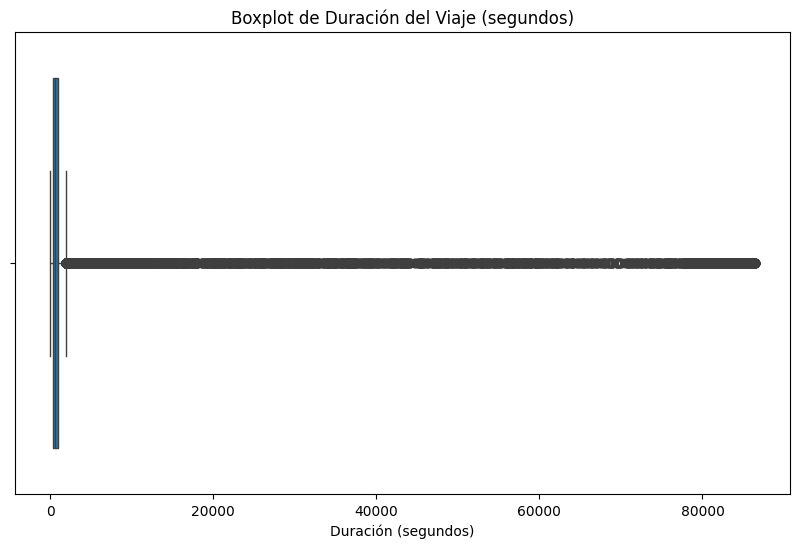

In [19]:
# Convertir la columna 'Duration' a números (segundos) para poder hacer un boxplot
taxi_df['Duration_seconds'] = taxi_df['Duration'].dt.total_seconds()

# Ahora puedes hacer un boxplot de 'Duration_seconds'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['Duration_seconds'])
plt.title('Boxplot de Duración del Viaje (segundos)')
plt.xlabel('Duración (segundos)')
plt.show()

In [20]:
taxi_df['Duration_minutes'] = taxi_df['Duration'].dt.total_seconds() / 60

# Crear rangos de minutos
bins = [0, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, float('inf')]
labels = ['0-11', '11-21', '21-31', '31-41', '41-51', '51-61', '61-71', '71-81', '81-91', '91-101', '101+']

# Agrupar por rangos de minutos y contar las carreras
taxi_df['Duration_range'] = pd.cut(taxi_df['Duration_minutes'], bins=bins, labels=labels, include_lowest=True)
race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()

race_count_by_range

Duration_range
0-11      4166743
11-21     2296039
21-31      744956
31-41      257810
41-51       98303
51-61       39536
61-71       15991
71-81        5992
81-91        2032
91-101        719
101+        21487
Name: Duration, dtype: int64

### patrones de duración de las carreras



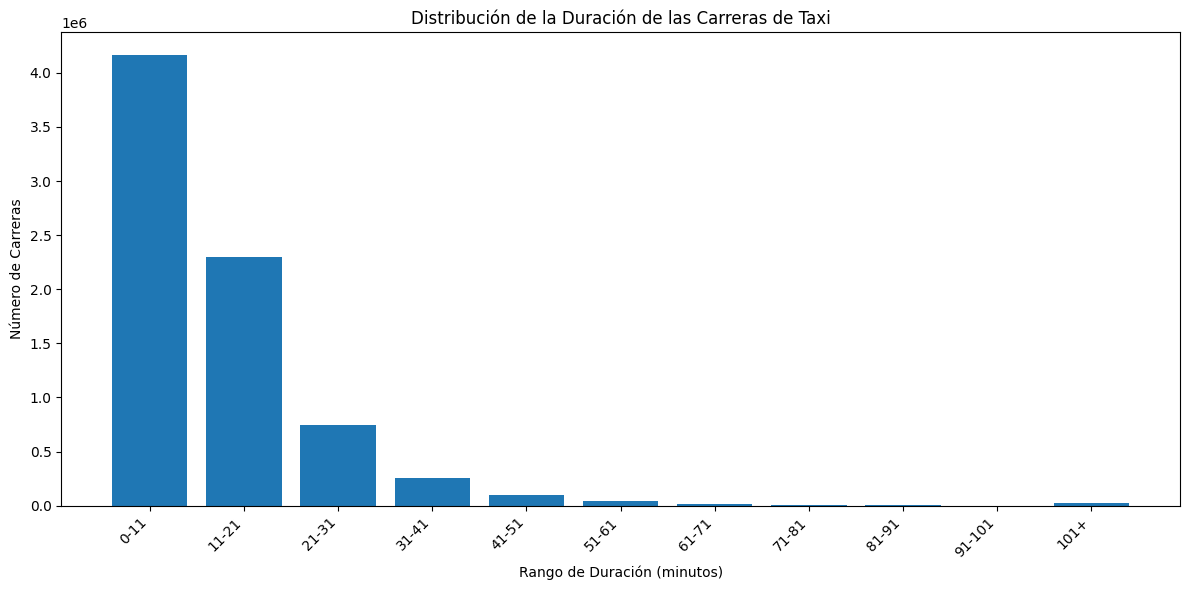

In [21]:
# Crear el gráfico de barras
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
plt.bar(race_count_by_range.index, race_count_by_range.values)

# Etiquetas y título del gráfico
plt.xlabel('Rango de Duración (minutos)')
plt.ylabel('Número de Carreras')
plt.title('Distribución de la Duración de las Carreras de Taxi')

# Rotar las etiquetas del eje x para una mejor legibilidad (opcional)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Inspección de datos faltantes y nulos



In [22]:
# Check for NaN values in the DataFrame
nan_counts = taxi_df.isna().sum()

# Print the counts of NaN values for each column
print(nan_counts)

# Optionally, you can also check if there are any NaN values in the entire DataFrame
has_nan = taxi_df.isnull().values.any()
print(f"\nDoes the DataFrame contain NaN values? {has_nan}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
RatecodeID          0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Zone_pickup         0
Zone_dropoff        0
Duration_seconds    0
Duration_minutes    0
Duration_range      0
dtype: int64

Does the DataFrame contain NaN values? False


In [23]:

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

Número de filas duplicadas: 1270


In [24]:
# Eliminar filas con valores NaN
taxi_df = taxi_df.dropna()

# Eliminar filas duplicadas
taxi_df = taxi_df.drop_duplicates()

# Verificar si se eliminaron los valores NaN y las filas duplicadas
nan_counts = taxi_df.isna().sum()
print(nan_counts)

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
RatecodeID          0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Zone_pickup         0
Zone_dropoff        0
Duration_seconds    0
Duration_minutes    0
Duration_range      0
dtype: int64
Número de filas duplicadas: 0


EDA

In [25]:
taxi_df['total_amount'].describe()

count    7.648338e+06
mean     1.549407e+01
std      2.599288e+02
min      0.000000e+00
25%      8.190000e+00
50%      1.116000e+01
75%      1.656000e+01
max      6.232617e+05
Name: total_amount, dtype: float64

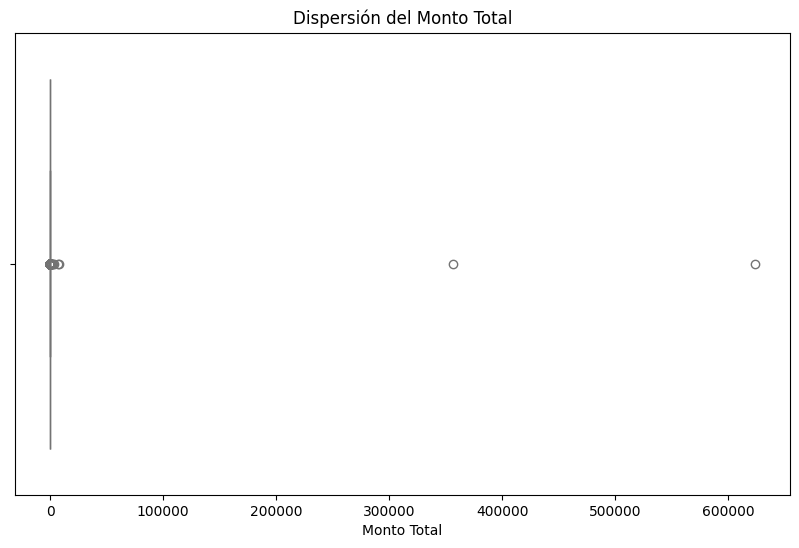

In [26]:
# Crear un boxplot para la distribución de 'total_amount'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['total_amount'], color='lightgreen')
plt.title('Dispersión del Monto Total')
plt.xlabel('Monto Total')
plt.show()

In [27]:
#Filtramos total_amount menores a 100
taxi_df = taxi_df[taxi_df['total_amount'] < 100]
print(taxi_df['total_amount'].describe())

count    7.642776e+06
mean     1.528406e+01
std      1.264956e+01
min      0.000000e+00
25%      8.190000e+00
50%      1.116000e+01
75%      1.656000e+01
max      9.998000e+01
Name: total_amount, dtype: float64


In [28]:
# Definir los intervalos y etiquetas (ajustado para que lleguen hasta 100)
bins = [0, 10, 20, 30, 50, 100]  # Rango de montos hasta 100
labels = ['0-10', '10-20', '20-30', '30-50', '50-100']

# Crear una nueva columna 'Amount_range' con los rangos en el DataFrame filtrado
taxi_df['Amount_range'] = pd.cut(taxi_df['total_amount'], bins=bins, labels=labels, right=False)

# Crear la tabla de frecuencias agrupadas
frequency_table_filtered = taxi_df['Amount_range'].value_counts().sort_index()

# Calcular la proporción dividiendo cada frecuencia por el total de registros
frequency_table_filtered_proportion = frequency_table_filtered / frequency_table_filtered.sum()

# Crear un DataFrame con ambas columnas: frecuencia y proporción
result_df = pd.DataFrame({
    'Frequency': frequency_table_filtered,
    'Proportion': frequency_table_filtered_proportion
})

# Mostrar la tabla de frecuencias con las proporciones
print(result_df)



              Frequency  Proportion
Amount_range                       
0-10            3168311    0.414550
10-20           3136788    0.410425
20-30            649655    0.085002
30-50            400416    0.052391
50-100           287606    0.037631


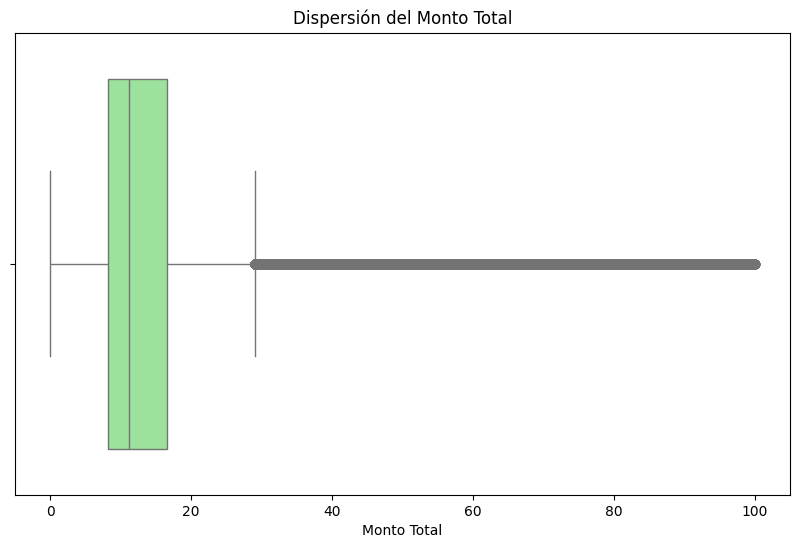

In [29]:
# Crear un boxplot para la distribución de 'total_amount'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['total_amount'], color='lightgreen')
plt.title('Dispersión del Monto Total')
plt.xlabel('Monto Total')
plt.show()

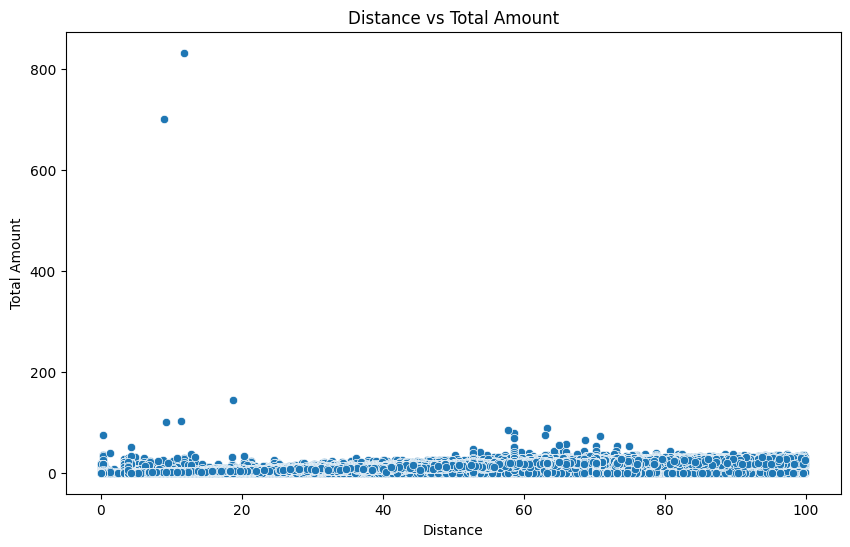

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_amount', y='Distance', data=taxi_df)
plt.title('Distance vs Total Amount')
plt.xlabel('Distance')
plt.ylabel('Total Amount')
plt.show()

### Tipos de pagos

In [31]:
# Contar las ocurrencias de cada tipo de pago
payment_type_counts = taxi_df['payment_type'].value_counts()

# Diccionario de traducción de los tipos de pago a español
payment_type_labels_es = {
    1: 'Tarjeta de crédito',
    2: 'Efectivo',
    3: 'Sin cargo',
    4: 'Disputa',
    5: 'Desconocido',
    6: 'Viaje anulado'
}

# Asignar los nombres en español a los códigos y mostrar los resultados
payment_type_counts_named_es = payment_type_counts.rename(payment_type_labels_es)
print(payment_type_counts_named_es)


payment_type
Tarjeta de crédito    5468832
Efectivo              2130268
Sin cargo               32679
Disputa                 10997
Name: count, dtype: int64


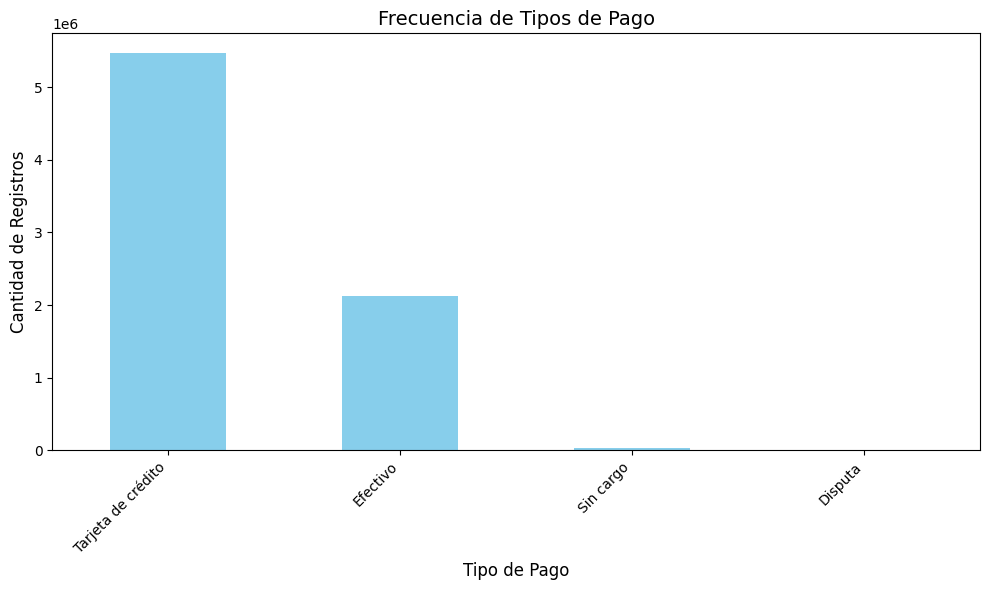

In [32]:
# Crear un gráfico de barras
plt.figure(figsize=(10, 6))
payment_type_counts_named_es.plot(kind='bar', color='skyblue')

# Añadir título y etiquetas
plt.title('Frecuencia de Tipos de Pago', fontsize=14)
plt.xlabel('Tipo de Pago', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)

# Mostrar las etiquetas en el eje x de forma legible
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

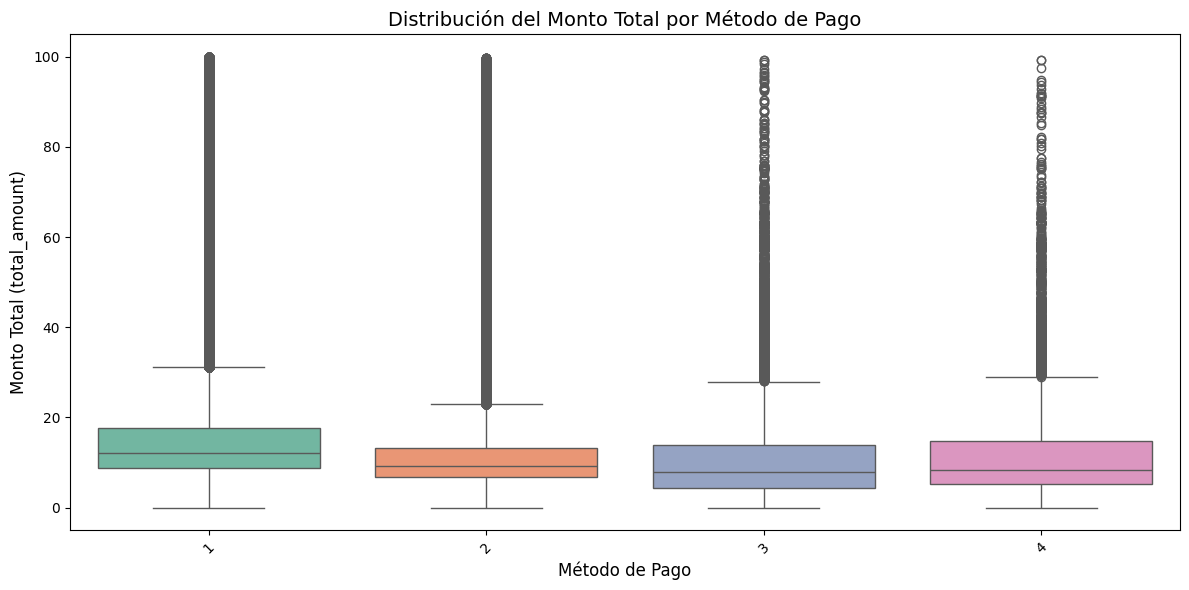

In [33]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='payment_type', y='total_amount', data=taxi_df, palette='Set2')

# Añadir título y etiquetas
plt.title('Distribución del Monto Total por Método de Pago', fontsize=14)
plt.xlabel('Método de Pago', fontsize=12)
plt.ylabel('Monto Total (total_amount)', fontsize=12)

# Rotar las etiquetas del eje x para que sean legibles
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

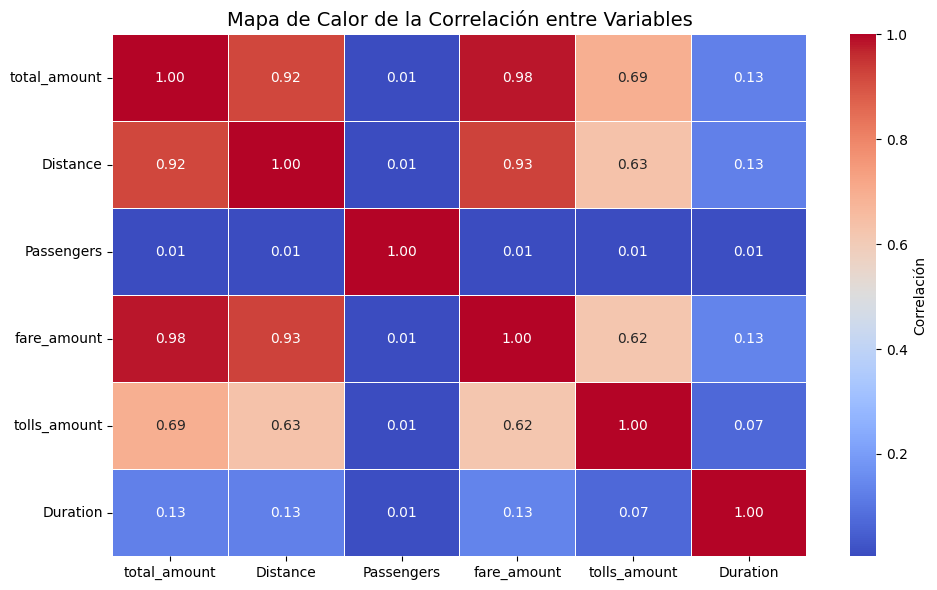

In [34]:
# Seleccionar solo las columnas numéricas para la correlación
numeric_columns = ['total_amount', 'Distance', 'Passengers', 'fare_amount', 'tolls_amount', 'Duration']

# Calcular la matriz de correlación
correlation_matrix = taxi_df[numeric_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlación'})


plt.title('Mapa de Calor de la Correlación entre Variables', fontsize=14)

plt.tight_layout()
plt.show()

In [36]:
import pickle

with open('taxi_df.pkl', 'wb') as f:
    pickle.dump(taxi_df, f)


In [35]:
# seleccion de variabls
print(taxi_df.columns)

Index(['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'RatecodeID',
       'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth',
       'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek',
       'payment_type', 'tolls_amount', 'Duration', 'Zone_pickup',
       'Zone_dropoff', 'Duration_seconds', 'Duration_minutes',
       'Duration_range', 'Amount_range'],
      dtype='object')


In [36]:
# DataFrame con las variables seleccionadas para los modelos de clustering
variables_clustering = [
    'total_amount',
    'Distance',
    'Passengers',
    'tolls_amount',
    'Duration_seconds',
    'payment_type',
    'RatecodeID'
]

# Crear una copia con solo esas columnas
df_clustering = taxi_df[variables_clustering].copy()

# Mostrar las primeras filas
df_clustering.head()

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID
0,9.95,1.5,1.0,0.0,400.0,1,1.0
1,16.30,2.6,1.0,0.0,1152.0,1,1.0
7,9.05,1.3,1.0,0.0,429.0,1,1.0
8,18.50,3.7,1.0,0.0,818.0,1,1.0
9,13.00,2.1,2.0,0.0,720.0,1,1.0


Comparación y Análisis:

Número de clusters:
En los resultados anteriores, DBSCAN identificó 81 clusters, mientras que en los resultados actuales, solo identificó 3 clusters.
Esta diferencia significativa se debe principalmente al aumento en el valor de min_samples (de 3 a 100) y eps (de 0.5 a 1).
Valores más altos de min_samples y eps hacen que DBSCAN sea más estricto al definir los clusters, lo que resulta en menos clusters y clusters más grandes y densos.
Puntos clasificados como ruido:
En los resultados anteriores, DBSCAN clasificó 470 puntos como ruido, mientras que en los resultados actuales clasificó 1120 puntos como ruido.
El aumento en el número de puntos clasificados como ruido también se debe al aumento en min_samples y eps.
Con valores más altos, DBSCAN requiere una mayor densidad para formar clusters, lo que resulta en que más puntos se clasifiquen como ruido.
Interpretación:
Los resultados anteriores sugieren que tus datos tienen muchos patrones locales y clusters pequeños.
Los resultados actuales sugieren que tus datos tienen patrones globales más grandes y que muchos de los patrones locales identificados anteriormente eran ruido.
La elección de qué resultados son más adecuados depende de tus objetivos de análisis. Si estás interesado en patrones globales, los resultados actuales pueden ser más útiles. Si estás interesado en patrones locales, los resultados anteriores pueden ser más útiles.
Ajuste de parámetros:
Los resultados actuales muestran que el ajuste de parámetros tiene un impacto significativo en los resultados de DBSCAN.
Es crucial experimentar con diferentes valores de eps y min_samples para encontrar los parámetros óptimos para tus datos y objetivos.
Conclusión:

import tensorflow as tf
from tensorflow import kerasEl aumento en min_samples y eps ha transformado significativamente los resultados de DBSCAN, pasando de muchos clusters pequeños a pocos clusters grandes y un mayor número de puntos clasificados como ruido. La elección de los parámetros óptimos depende de tus objetivos de análisis y de las características de tus datos.

## AUTOENCODER

El código presenta dos implementaciones del uso de un autoencoder para la segmentación de datos de viajes de taxi, buscando reducir la dimensionalidad y facilitar la identificación de clústeres mediante K-means. La primera implementación realiza un entrenamiento básico del autoencoder sobre una muestra de los datos, estandarizando las características numéricas y utilizando una arquitectura de red neuronal secuencial con capas densas y activación ReLU. El autoencoder se compila con el optimizador Adam y la función de pérdida MSE, entrenándose durante 10 epochs con un tamaño de lote de 32. La representación latente obtenida del encoder se utiliza para aplicar K-means, asignando clústeres a la muestra original.

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Suponiendo que tienes taxi_df_sample y columns_to_use definidos

# 1. Preparación de los datos de la muestra
taxi_df_sample_numeric = taxi_df_sample[columns_to_use].astype(np.float32)

# 2. Inicializar y ajustar el StandardScaler en la muestra
scaler = StandardScaler()
taxi_df_sample_scaled = scaler.fit_transform(taxi_df_sample_numeric)

# 3. Construcción del autoencoder
input_dim = taxi_df_sample_scaled.shape[1]  # Usar la dimensión correcta de los datos escalados
encoding_dim = 3  # Dimensión de la representación latente

autoencoder = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    keras.layers.Dense(encoding_dim, activation='relu'),  # Capa de codificación (representación latente)
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(input_dim)  # Capa de decodificación
])

# 4. Compilación del autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# 5. Entrenamiento del autoencoder (usando GPU)
with tf.device('/GPU:0'):  # Asegúrate de que tu GPU esté configurada como '/GPU:0'
    autoencoder.fit(taxi_df_sample_scaled, taxi_df_sample_scaled, epochs=10, batch_size=32)

# 6. Obtención de la representación latente
encoder = keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[1].output)
latent_representation = encoder.predict(taxi_df_sample_scaled)

# 7. Clustering en la representación latente (K-means)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')  # Ajusta n_clusters según sea necesario
taxi_df_sample['Autoencoder_Cluster'] = kmeans.fit_predict(latent_representation)

Epoch 1/10
2393/2393 [==============================] - 4s 1ms/step - loss: 0.0994
Epoch 2/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0174
Epoch 3/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0117
Epoch 4/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0108
Epoch 5/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0087
Epoch 6/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0087
Epoch 7/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0078
Epoch 8/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0076
Epoch 9/10
2393/2393 [==============================] - 3s 1ms/step - loss: 0.0080
Epoch 10/10
2393/2393 [==============================] - 1s 436us/step


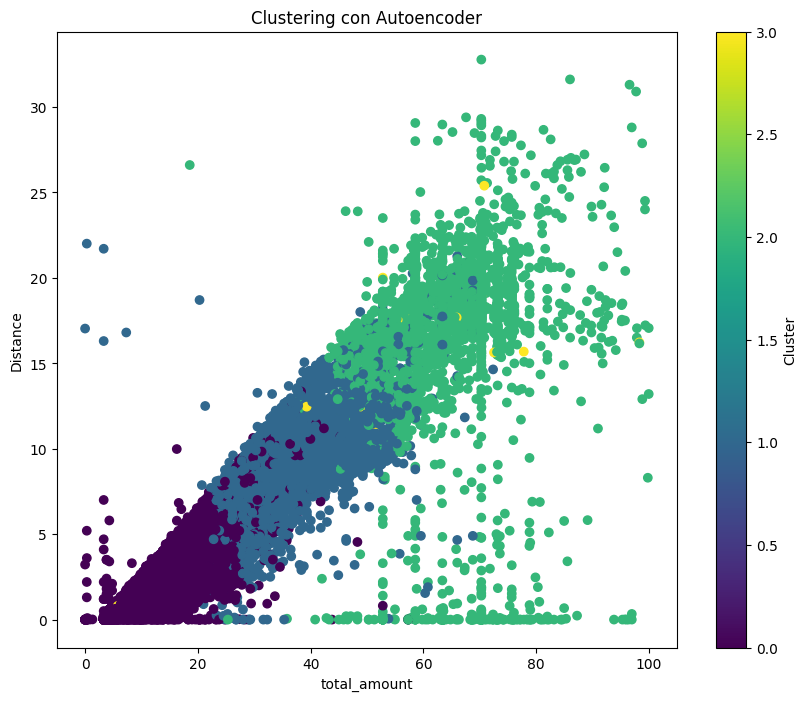

         total_amount  Distance  Autoencoder_Cluster
3910851         11.16      1.07                    0
7317470         23.75      4.30                    0
6593402         68.56     19.69                    2
258640           7.56      1.09                    0
7487742          7.30      0.80                    0


In [ ]:
# 8. Visualización de los resultados (opcional)
plt.figure(figsize=(10, 8))
plt.scatter(taxi_df_sample['total_amount'], taxi_df_sample['Distance'], c=taxi_df_sample['Autoencoder_Cluster'], cmap='viridis')
plt.title('Clustering con Autoencoder')
plt.xlabel('total_amount')
plt.ylabel('Distance')
plt.colorbar(label='Cluster')
plt.show()

# 9. Ver las primeras filas con el cluster asignado (opcional)
print(taxi_df_sample[['total_amount', 'Distance', 'Autoencoder_Cluster']].head())

La segunda implementación optimiza el proceso de entrenamiento al incorporar la técnica de "Early Stopping" para evitar el sobreajuste. Primero, divide la muestra en conjuntos de entrenamiento y validación, permitiendo monitorear el rendimiento del modelo en datos no vistos durante el entrenamiento. El StandardScaler se ajusta solo en el conjunto de entrenamiento para prevenir la fuga de información, y se aplica la misma escala a la validación. El callback EarlyStopping se configura para detener el entrenamiento si la pérdida de validación no mejora durante 5 epochs consecutivos, restaurando los mejores pesos del modelo. El entrenamiento se realiza con un máximo de 100 epochs, pero se detendrá automáticamente si se cumple la condición de "Early Stopping". Esto ajusta dinámicamente el número de epochs necesarios, previniendo el sobreajuste y optimizando el tiempo de entrenamiento. El tamaño del batch se mantiene en 32, equilibrando la eficiencia computacional y el uso de memoria. Finalmente, la representación latente se obtiene y se utiliza para aplicar K-means, similar a la primera 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suponiendo que tienes taxi_df_sample y columns_to_use definidos

# 1. Preparación de los datos de la muestra
taxi_df_sample_numeric = taxi_df_sample[columns_to_use].astype(np.float32)

# 2. Dividir los datos en entrenamiento y validación
train_data, val_data = train_test_split(taxi_df_sample_numeric, test_size=0.2, random_state=42)

# 3. Inicializar y ajustar el StandardScaler en el conjunto de entrenamiento
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data) # Aplicar la misma escala al conjunto de validación

# 4. Construcción del autoencoder
input_dim = train_data_scaled.shape[1]  # Usar la dimensión correcta de los datos escalados
encoding_dim = 3  # Dimensión de la representación latente

autoencoder = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    keras.layers.Dense(encoding_dim, activation='relu'),  # Capa de codificación (representación latente)
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(input_dim)  # Capa de decodificación
])

# 5. Compilación del autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# 6. Implementación de Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Métrica a monitorear (pérdida en el conjunto de validación)
    patience=5,         # Número de epochs sin mejora antes de detener
    restore_best_weights=True  # Restaura los pesos del modelo al mejor epoch
)

# 7. Entrenamiento del autoencoder (usando GPU y Early Stopping)
with tf.device('/GPU:0'):  # Asegúrate de que tu GPU esté configurada como '/GPU:0'
    history = autoencoder.fit(
        train_data_scaled, train_data_scaled,
        epochs=100,  # Aumenta el número máximo de epochs
        batch_size=32,
        validation_data=(val_data_scaled, val_data_scaled),
        callbacks=[early_stopping]
    )

# 8. Obtención de la representación latente para todo el conjunto de muestra
taxi_df_sample_scaled = scaler.transform(taxi_df_sample_numeric) # Escalar toda la muestra
encoder = keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[1].output)
latent_representation = encoder.predict(taxi_df_sample_scaled)

# 9. Clustering en la representación latente (K-means)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')  # Ajusta n_clusters según sea necesario
taxi_df_sample['Autoencoder_Cluster'] = kmeans.fit_predict(latent_representation)

Epoch 1/100
1914/1914 [==============================] - 3s 1ms/step - loss: 0.0688 - val_loss: 0.0218
Epoch 2/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0217 - val_loss: 0.0155
Epoch 3/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0192 - val_loss: 0.0165
Epoch 4/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0188 - val_loss: 0.0131
Epoch 5/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0171 - val_loss: 0.0121
Epoch 6/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0146 - val_loss: 0.0117
Epoch 7/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0140 - val_loss: 0.0103
Epoch 8/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0129 - val_loss: 0.0095
Epoch 9/100
1914/1914 [==============================] - 2s 1ms/step - loss: 0.0120 - val_loss: 0.0089
Epoch 10/100
1914/1914 [==============================] - 2s 1ms/step - l

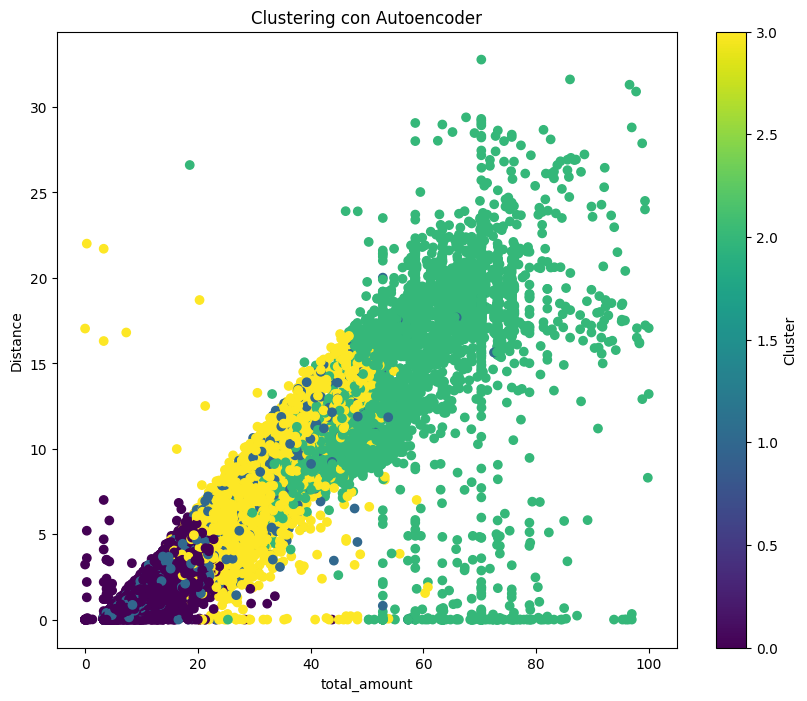

         total_amount  Distance  Autoencoder_Cluster
3910851         11.16      1.07                    0
7317470         23.75      4.30                    3
6593402         68.56     19.69                    2
258640           7.56      1.09                    0
7487742          7.30      0.80                    0


In [ ]:
# 10. Visualización de los resultados (opcional)
plt.figure(figsize=(10, 8))
plt.scatter(taxi_df_sample['total_amount'], taxi_df_sample['Distance'], c=taxi_df_sample['Autoencoder_Cluster'], cmap='viridis')
plt.title('Clustering con Autoencoder')
plt.xlabel('total_amount')
plt.ylabel('Distance')
plt.colorbar(label='Cluster')
plt.show()

# 11. Ver las primeras filas con el cluster asignado (opcional)
print(taxi_df_sample[['total_amount', 'Distance', 'Autoencoder_Cluster']].head())